<a href="https://colab.research.google.com/github/sandinaniaaryan-afk/ML/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

def label_encode(column):
    unique_values = column.unique()
    mapping = {value: index for index, value in enumerate(unique_values)}
    encoded = column.map(mapping)
    return encoded, mapping

df = pd.read_excel('Lab Session Data.xlsx', sheet_name='marketing_campaign')

df["Recency"], recency_map = label_encode(df["Recency"])

print(df.head())
print(recency_map)
df.to_excel("Lab Session Data_Encoded.xlsx", sheet_name="marketing_campaign", index=False)



     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00        0       635  ...                  7   
1  2014-08-03 00:00:00        1        11  ...                  5   
2           21-08-2013        2       426  ...                  4   
3  2014-10-02 00:00:00        2        11  ...                  6   
4           19-01-2014        3       173  ...                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  \
0             0             0            

In [ ]:
from sklearn.preprocessing import OneHotEncoder
def one_hot_encode(column):

    encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore"
    )

    encoded_data = encoder.fit_transform(column.to_frame())

    encoded_df = pd.DataFrame(
        encoded_data,
        columns=encoder.get_feature_names_out([column.name]),
        index=column.index
    )

    return encoded_df

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.read_excel(
    "Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

def label_encode(column):

    encoder = LabelEncoder()

    encoded_column = encoder.fit_transform(column)

    mapping = {}

    for index, value in enumerate(encoder.classes_):
        mapping[value] = index

    return encoded_column, mapping


def one_hot_encode(column):

    encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore"
    )

    encoded_data = encoder.fit_transform(column.to_frame())

    encoded_df = pd.DataFrame(
        encoded_data,
        columns=encoder.get_feature_names_out([column.name]),
        index=column.index
    )

    return encoded_df


df["Education"], education_map = label_encode(df["Education"])

print("Education Mapping")
print(education_map)

marital_encoded = one_hot_encode(df["Marital_Status"])

df = pd.concat(
    [df.drop("Marital_Status", axis=1), marital_encoded],
    axis=1
)

with pd.ExcelWriter(
    "Lab Session Data.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    df.to_excel(
        writer,
        sheet_name="marketing_campaign",
        index=False
    )

print("Encoding completed successfully.")


Education Mapping
{'2n Cycle': 0, 'Basic': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
Encoding completed successfully.


In [5]:
import pandas as pd

df = pd.read_excel(
    "Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

def minkowski_distance(point1, point2, p):

    distance = 0

    for i in range(len(point1)):
        distance += (abs(point1[i] - point2[i])) ** p

    distance = distance ** (1 / p)

    return distance

customer1 = df.iloc[0].drop(["ID", "Dt_Customer"])
customer2 = df.iloc[1].drop(["ID", "Dt_Customer"])

customer1 = customer1.astype(float).values
customer2 = customer2.astype(float).values

manhattan = minkowski_distance(customer1, customer2, 1)
euclidean = minkowski_distance(customer1, customer2, 2)

print("Manhattan Distance:", manhattan)
print("Euclidean Distance:", euclidean)

Manhattan Distance: 13431.0
Euclidean Distance: 11825.004228329053


p	Distance
1 	 13431.0
2 	 11825.004228329053
3 	 11794.975787215702
4 	 11794.036213715512
5 	 11794.001454169289
6 	 11794.000061245159
7 	 11794.00000266629
8 	 11794.000000118998
9 	 11794.00000000541
10 	 11794.000000000256


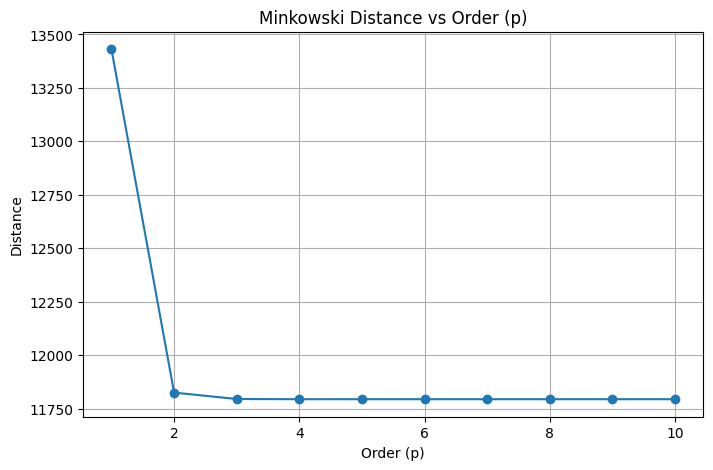

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

customer1 = numeric_df.iloc[0].drop("ID").values
customer2 = numeric_df.iloc[1].drop("ID").values

def minkowski_distance(point1, point2, p):

    distance = 0

    for i in range(len(point1)):
        distance += abs(point1[i] - point2[i]) ** p

    distance = distance ** (1 / p)

    return distance

p_values = []
distances = []

for p in range(1, 11):

    d = minkowski_distance(customer1, customer2, p)

    p_values.append(p)

    distances.append(d)

print("p\tDistance")
for p, d in zip(p_values, distances):
    print(p, "\t", d)

plt.figure(figsize=(8,5))
plt.plot(p_values, distances, marker='o')
plt.title("Minkowski Distance vs Order (p)")
plt.xlabel("Order (p)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [10]:
import pandas as pd
from scipy.spatial.distance import minkowski

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

customer1 = numeric_df.iloc[0].drop("ID").values.astype(float)
customer2 = numeric_df.iloc[1].drop("ID").values.astype(float)

def minkowski_distance(point1, point2, p):

    distance = 0

    for i in range(len(point1)):
        distance += abs(point1[i] - point2[i]) ** p

    distance = distance ** (1 / p)

    return distance

print("p\tOwn Function\tSciPy Function")

for p in range(1, 11):

    own_distance = minkowski_distance(customer1, customer2, p)

    scipy_distance = minkowski(customer1, customer2, p)

    print(f"{p}\t{own_distance:.6f}\t{scipy_distance:.6f}")

p	Own Function	SciPy Function
1	13431.000000	13431.000000
2	11825.004228	11825.004228
3	11794.975787	11794.975787
4	11794.036214	11794.036214
5	11794.001454	11794.001454
6	11794.000061	11794.000061
7	11794.000003	11794.000003
8	11794.000000	11794.000000
9	11794.000000	11794.000000
10	11794.000000	11794.000000


In [11]:
import pandas as pd
import numpy as np
import math

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

A = numeric_df.iloc[0].drop("ID").values.astype(float)
B = numeric_df.iloc[1].drop("ID").values.astype(float)

def dot_product(vector1, vector2):

    dot = 0

    for i in range(len(vector1)):
        dot += vector1[i] * vector2[i]

    return dot


def euclidean_norm(vector):

    norm = 0

    for i in range(len(vector)):
        norm += vector[i] ** 2

    norm = math.sqrt(norm)

    return norm


my_dot = dot_product(A, B)
my_norm_A = euclidean_norm(A)
my_norm_B = euclidean_norm(B)

numpy_dot = np.dot(A, B)
numpy_norm_A = np.linalg.norm(A)
numpy_norm_B = np.linalg.norm(B)

print("----------- Dot Product -----------")
print("My Function      :", my_dot)
print("NumPy dot()      :", numpy_dot)

print("\n----------- Euclidean Norm -----------")
print("Vector A")
print("My Function      :", my_norm_A)
print("NumPy norm()     :", numpy_norm_A)

print("\nVector B")
print("My Function      :", my_norm_B)
print("NumPy norm()     :", numpy_norm_B)

print("\nComparison")

if abs(my_dot - numpy_dot) < 1e-6:
    print("Dot Product : SAME")
else:
    print("Dot Product : DIFFERENT")

if abs(my_norm_A - numpy_norm_A) < 1e-6:
    print("Norm of Vector A : SAME")
else:
    print("Norm of Vector A : DIFFERENT")

if abs(my_norm_B - numpy_norm_B) < 1e-6:
    print("Norm of Vector B : SAME")
else:
    print("Norm of Vector B : DIFFERENT")

----------- Dot Product -----------
My Function      : 2698185165.0
NumPy dot()      : 2698185165.0

----------- Euclidean Norm -----------
Vector A
My Function      : 58177.442260725074
NumPy norm()     : 58177.442260725074

Vector B
My Function      : 46385.19448056675
NumPy norm()     : 46385.19448056675

Comparison
Dot Product : SAME
Norm of Vector A : SAME
Norm of Vector B : SAME


In [12]:
import pandas as pd
import math

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

if "ID" in numeric_df.columns:
    numeric_df = numeric_df.drop("ID", axis=1)

def calculate_mean(data):

    total = 0

    for value in data:
        total += value

    mean = total / len(data)

    return mean


def calculate_variance(data):

    mean = calculate_mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    variance = variance / len(data)

    return variance


def calculate_standard_deviation(data):

    variance = calculate_variance(data)

    standard_deviation = math.sqrt(variance)

    return standard_deviation


def dataset_statistics(dataset):

    print("{:<30} {:>15} {:>15} {:>20}".format("Feature","Mean","Variance","Standard Deviation"))
    print("-"*85)

    for column in dataset.columns:

        data = dataset[column].values.astype(float)

        mean = calculate_mean(data)

        variance = calculate_variance(data)

        standard_deviation = calculate_standard_deviation(data)

        print("{:<30} {:>15.4f} {:>15.4f} {:>20.4f}".format(column,mean,variance,standard_deviation))


dataset_statistics(numeric_df)

Feature                                   Mean        Variance   Standard Deviation
-------------------------------------------------------------------------------------
Year_Birth                           1968.8058        143.5538              11.9814
Education                               2.3937          1.2646               1.1245
Income                                     nan             nan                  nan
Kidhome                                 0.4442          0.2897               0.5383
Teenhome                                0.5062          0.2964               0.5444
Recency                                49.1094        838.4492              28.9560
MntWines                              303.9357     113247.2253             336.5223
MntFruits                              26.3022       1581.2198              39.7646
MntMeatProducts                       166.9500      50924.6850             225.6650
MntFishProducts                        37.5254       2982.9931            

In [13]:
import pandas as pd
import numpy as np
import math

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include=["number"])

if "ID" in numeric_df.columns:
    numeric_df = numeric_df.drop("ID", axis=1)

def calculate_mean(data):

    total = 0

    for value in data:
        total += value

    return total / len(data)


def calculate_variance(data):

    mean = calculate_mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)


def calculate_standard_deviation(data):

    variance = calculate_variance(data)

    return math.sqrt(variance)


print("{:<30}{:>15}{:>15}{:>15}{:>15}".format(
    "Feature",
    "My Mean",
    "NumPy Mean",
    "My Std",
    "NumPy Std"
))

print("-"*90)

for column in numeric_df.columns:

    data = numeric_df[column].values.astype(float)

    my_mean = calculate_mean(data)

    numpy_mean = np.mean(data)

    my_std = calculate_standard_deviation(data)

    numpy_std = np.std(data)

    print("{:<30}{:>15.4f}{:>15.4f}{:>15.4f}{:>15.4f}".format(
        column,
        my_mean,
        numpy_mean,
        my_std,
        numpy_std
    ))

Feature                               My Mean     NumPy Mean         My Std      NumPy Std
------------------------------------------------------------------------------------------
Year_Birth                          1968.8058      1968.8058        11.9814        11.9814
Education                              2.3937         2.3937         1.1245         1.1245
Income                                    nan            nan            nan            nan
Kidhome                                0.4442         0.4442         0.5383         0.5383
Teenhome                               0.5062         0.5062         0.5444         0.5444
Recency                               49.1094        49.1094        28.9560        28.9560
MntWines                             303.9357       303.9357       336.5223       336.5223
MntFruits                             26.3022        26.3022        39.7646        39.7646
MntMeatProducts                      166.9500       166.9500       225.6650       225.6650

Mean = 52247.25135379061
Variance = 633397830.1872728

Histogram Counts
[1654  554    7    0    0    0    0    0    0    1]

Bin Edges
[  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]


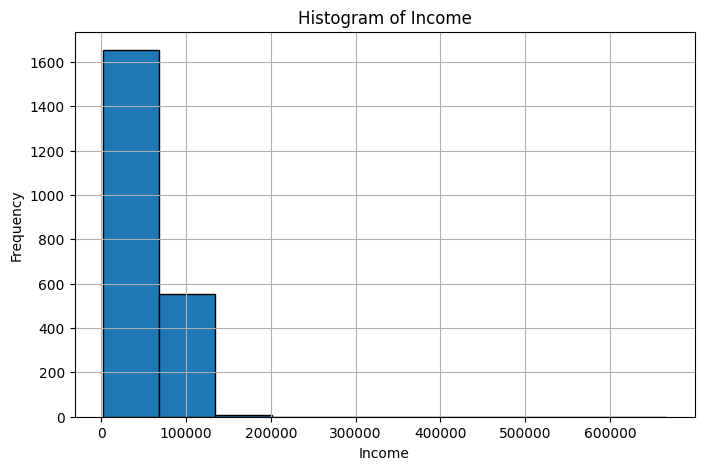

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

feature = df["Income"].dropna()

mean = np.mean(feature)

variance = np.var(feature)

print("Mean =", mean)
print("Variance =", variance)

counts, bins = np.histogram(feature, bins=10)

print("\nHistogram Counts")
print(counts)

print("\nBin Edges")
print(bins)

plt.figure(figsize=(8,5))

plt.hist(feature, bins=10, edgecolor="black")

plt.title("Histogram of Income")

plt.xlabel("Income")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()